In [1]:
from detectron2.config import get_cfg
from detectron2.projects.deeplab import add_deeplab_config
from mask2former import add_maskformer2_config

In [2]:
cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

#cfg.merge_from_file('configs/swin/maskformer2_swin_base_384_bs16_50ep.yaml')
cfg.merge_from_file('configs/panoptic_segmentation/maskformer2_R50_bs16_50ep.yaml')
cfg.MODEL.RESNETS.NORM = "BN"
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_swin_large_IN21k_384_bs16_100ep/model_final_f07440.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_swin_base_384_bs16_50ep/model_final_f6e0f6.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_R50_bs16_50ep/model_final_3c8ec9.pkl'
#cfg.MODEL.WEIGHTS = './elasticdepthresnet_ckpt.pth'
#cfg.MODEL.WEIGHTS = './fullelasticm2f_ckpt.pth'
cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl'
cfg.OUTPUT_DIR = "./test_output4/"
import torch
torch.cuda.set_device(2)

In [3]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val_panoptic_with_sem_seg',)
  TRAIN: ('coco_2017_train_panoptic',)
GLOBAL:
  HACK: 1.0
INPUT:
  COLOR_AUG_SSD: False
  CROP:
    ENABLED: False
    SINGLE_CATEGORY_MAX_AREA: 1.0
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  DATASET_MAPPER_NAME: coco_panoptic_lsj
  FORMAT: RGB
  IMAGE_SIZE: 1024
  MASK_FORMAT: polygon
  MAX_SCALE: 2.0
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SCALE: 0.1
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (800,)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
  SIZE_DIVISIBILITY: -1
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET:

In [4]:
cfg.freeze()

In [5]:
from detectron2.engine import (
    DefaultWSTrainer,
)
class Trainer(DefaultWSTrainer):
    """
    Extension of the Trainer class adapted to MaskFormer.
    """

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        """
        Create evaluator(s) for a given dataset.
        This uses the special metadata "evaluator_type" associated with each
        builtin dataset. For your own dataset, you can simply create an
        evaluator manually in your script and do not have to worry about the
        hacky if-else logic here.
        """
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        evaluator_list = []
        evaluator_type = MetadataCatalog.get(dataset_name).evaluator_type
        # semantic segmentation
        if evaluator_type in ["sem_seg", "ade20k_panoptic_seg"]:
            evaluator_list.append(
                SemSegEvaluator(
                    dataset_name,
                    distributed=True,
                    output_dir=output_folder,
                )
            )
        # instance segmentation
        if evaluator_type == "coco":
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        # panoptic segmentation
        if evaluator_type in [
            "coco_panoptic_seg",
            "ade20k_panoptic_seg",
            "cityscapes_panoptic_seg",
            "mapillary_vistas_panoptic_seg",
        ]:
            if cfg.MODEL.MASK_FORMER.TEST.PANOPTIC_ON:
                evaluator_list.append(COCOPanopticEvaluator(dataset_name, output_folder))
        # COCO
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Mapillary Vistas
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Cityscapes
        if evaluator_type == "cityscapes_instance":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesInstanceEvaluator(dataset_name)
        if evaluator_type == "cityscapes_sem_seg":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesSemSegEvaluator(dataset_name)
        if evaluator_type == "cityscapes_panoptic_seg":
            if cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesSemSegEvaluator(dataset_name))
            if cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesInstanceEvaluator(dataset_name))
        # ADE20K
        if evaluator_type == "ade20k_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        # LVIS
        if evaluator_type == "lvis":
            return LVISEvaluator(dataset_name, output_dir=output_folder)
        if len(evaluator_list) == 0:
            raise NotImplementedError(
                "no Evaluator for the dataset {} with the type {}".format(
                    dataset_name, evaluator_type
                )
            )
        elif len(evaluator_list) == 1:
            return evaluator_list[0]
        return DatasetEvaluators(evaluator_list)

    @classmethod
    def build_train_loader(cls, cfg):
        # Semantic segmentation dataset mapper
        if cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_semantic":
            mapper = MaskFormerSemanticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Panoptic segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_panoptic":
            mapper = MaskFormerPanopticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Instance segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_instance":
            mapper = MaskFormerInstanceDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco instance segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_instance_lsj":
            mapper = COCOInstanceNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco panoptic segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_panoptic_lsj":
            mapper = COCOPanopticNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        else:
            mapper = None
            return build_detection_train_loader(cfg, mapper=mapper)

    @classmethod
    def build_lr_scheduler(cls, cfg, optimizer):
        """
        It now calls :func:`detectron2.solver.build_lr_scheduler`.
        Overwrite it if you'd like a different scheduler.
        """
        return build_lr_scheduler(cfg, optimizer)

    @classmethod
    def build_optimizer(cls, cfg, model):
        weight_decay_norm = cfg.SOLVER.WEIGHT_DECAY_NORM
        weight_decay_embed = cfg.SOLVER.WEIGHT_DECAY_EMBED

        defaults = {}
        defaults["lr"] = cfg.SOLVER.BASE_LR
        defaults["weight_decay"] = cfg.SOLVER.WEIGHT_DECAY

        norm_module_types = (
            torch.nn.BatchNorm1d,
            torch.nn.BatchNorm2d,
            torch.nn.BatchNorm3d,
            torch.nn.SyncBatchNorm,
            # NaiveSyncBatchNorm inherits from BatchNorm2d
            torch.nn.GroupNorm,
            torch.nn.InstanceNorm1d,
            torch.nn.InstanceNorm2d,
            torch.nn.InstanceNorm3d,
            torch.nn.LayerNorm,
            torch.nn.LocalResponseNorm,
        )

        params: List[Dict[str, Any]] = []
        memo: Set[torch.nn.parameter.Parameter] = set()
        for module_name, module in model.named_modules():
            for module_param_name, value in module.named_parameters(recurse=False):
                if not value.requires_grad:
                    continue
                # Avoid duplicating parameters
                if value in memo:
                    continue
                memo.add(value)

                hyperparams = copy.copy(defaults)
                if "backbone" in module_name:
                    hyperparams["lr"] = hyperparams["lr"] * cfg.SOLVER.BACKBONE_MULTIPLIER
                if (
                    "relative_position_bias_table" in module_param_name
                    or "absolute_pos_embed" in module_param_name
                ):
                    print(module_param_name)
                    hyperparams["weight_decay"] = 0.0
                if isinstance(module, norm_module_types):
                    hyperparams["weight_decay"] = weight_decay_norm
                if isinstance(module, torch.nn.Embedding):
                    hyperparams["weight_decay"] = weight_decay_embed
                params.append({"params": [value], **hyperparams})

        def maybe_add_full_model_gradient_clipping(optim):
            # detectron2 doesn't have full model gradient clipping now
            clip_norm_val = cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE
            enable = (
                cfg.SOLVER.CLIP_GRADIENTS.ENABLED
                and cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model"
                and clip_norm_val > 0.0
            )

            class FullModelGradientClippingOptimizer(optim):
                def step(self, closure=None):
                    all_params = itertools.chain(*[x["params"] for x in self.param_groups])
                    torch.nn.utils.clip_grad_norm_(all_params, clip_norm_val)
                    super().step(closure=closure)

            return FullModelGradientClippingOptimizer if enable else optim

        optimizer_type = cfg.SOLVER.OPTIMIZER
        if optimizer_type == "SGD":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.SGD)(
                params, cfg.SOLVER.BASE_LR, momentum=cfg.SOLVER.MOMENTUM
            )
        elif optimizer_type == "ADAMW":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.AdamW)(
                params, cfg.SOLVER.BASE_LR
            )
        else:
            raise NotImplementedError(f"no optimizer type {optimizer_type}")
        if not cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model":
            optimizer = maybe_add_gradient_clipping(cfg, optimizer)
        return optimizer

    @classmethod
    def test_with_TTA(cls, cfg, model):
        logger = logging.getLogger("detectron2.trainer")
        # In the end of training, run an evaluation with TTA.
        logger.info("Running inference with test-time augmentation ...")
        model = SemanticSegmentorWithTTA(cfg, model)
        evaluators = [
            cls.build_evaluator(
                cfg, name, output_folder=os.path.join(cfg.OUTPUT_DIR, "inference_TTA")
            )
            for name in cfg.DATASETS.TEST
        ]
        res = cls.test(cfg, model, evaluators)
        res = OrderedDict({k + "_TTA": v for k, v in res.items()})
        return res

In [6]:
import torch
import copy
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    DatasetEvaluators,
    LVISEvaluator,
    SemSegEvaluator,
    verify_results,
)
from mask2former import (
    COCOInstanceNewBaselineDatasetMapper,
    COCOPanopticNewBaselineDatasetMapper,
    InstanceSegEvaluator,
    MaskFormerInstanceDatasetMapper,
    MaskFormerPanopticDatasetMapper,
    MaskFormerSemanticDatasetMapper,
    SemanticSegmentorWithTTA,
    add_maskformer2_config,
)
from detectron2.data import MetadataCatalog, build_detection_train_loader
from detectron2.projects.deeplab import build_lr_scheduler



In [7]:
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    print(f"Number of CUDA devices: {num_devices}")
    for i in range(num_devices):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No CUDA devices available.")

Number of CUDA devices: 8
Device 0: NVIDIA A40
Device 1: NVIDIA A40
Device 2: NVIDIA A40
Device 3: NVIDIA A40
Device 4: NVIDIA A40
Device 5: NVIDIA A40
Device 6: NVIDIA A40
Device 7: NVIDIA A40


In [8]:
print(cfg.OUTPUT_DIR)
print(cfg.MODEL.WEIGHTS)
#print(cfg.MODEL.WEIGHTS)


./test_output4/
https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl


In [41]:
import cv2
im = cv2.imread("./planetopview1.png")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

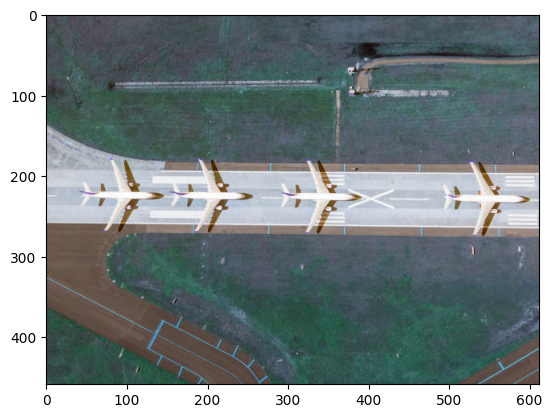

In [42]:
plt.imshow(im)

In [43]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
predictor.model.set_max_net()

#predictor.model.backbone.set_active_subnet([1,1,1,1])
outputs = predictor(im)

[01/06 04:42:04 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl ...


Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...
Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_track

In [44]:
!pwd
#print(predictor.model.backbone.layers)
all_keys = predictor.model.backbone.state_dict().keys()
#print(all_keys)
#print("layers.0.blocks.0.attn.relative_position_bias_table" in all_keys)
#print(predictor.model.backbone.layers[2].downsample)
#print(type(predictor.model.backbone.state_dict()))
#print(predictor.model.backbone.layers[2].blocks[0].attn.relative_position_bias_table.shape)
#'layers.2.blocks.0.attn.qkv.weight'
#print(predictor.model.backbone.layers[2].blocks.state_dict().keys())
#print(predictor.model)

/home/akhare39/animesh/wsobjdet


In [45]:
#torch.save(predictor.model.backbone, "ckpts/COCO_M2F_SWIN_B_InstanceSeg.pt")

In [46]:
#torch.save({"model":predictor.model.backbone.state_dict()}, "ckpts/COCO_M2F_SWIN_B_InstanceSeg_state_dict.pth")

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [6, 6, 6,  ..., 2, 2, 2],
        [6, 6, 6,  ..., 2, 2, 0],
        [6, 6, 6,  ..., 2, 2, 0]], device='cuda:2', dtype=torch.int32)
Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(550, 734, 3)


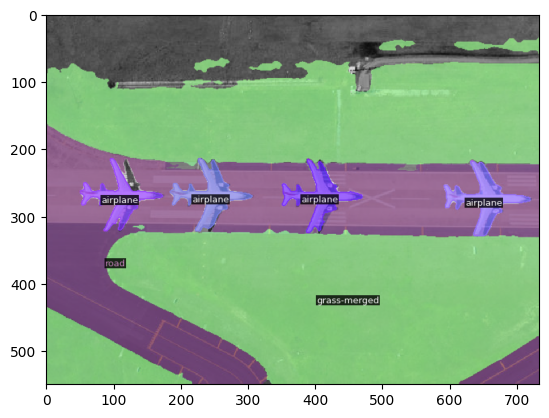

In [47]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
print(outputs["panoptic_seg"][0])
panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(panoptic_result.shape)
plt.imshow(panoptic_result)

In [16]:
#!wget http://images.cocodataset.org/val2017/000000001584.jpg -q -O input.jpg
!wget http://images.cocodataset.org/val2017/000000005477.jpg -q -O input.jpg
im = cv2.imread("./input.jpg")


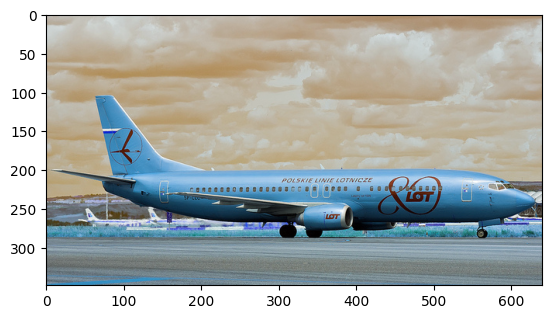

In [17]:
plt.imshow(im)

In [18]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
#predictor.model.backbone.set_active_subnet([0, 1, 3, 0])
outputs = predictor(im)


Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...
Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_track

In [19]:
#print(outputs)

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(418, 768, 3)


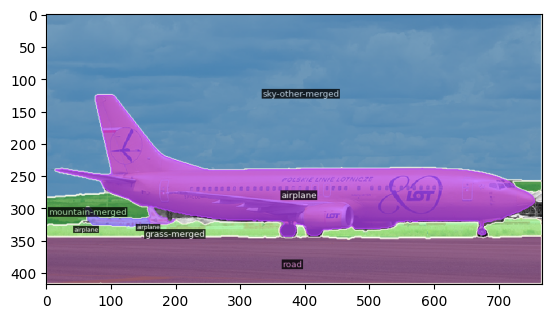

In [20]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(panoptic_result.shape)
plt.imshow(panoptic_result)

In [21]:
trainer = Trainer(cfg)

[01/05 22:40:25 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


[01/05 22:40:32 d2.data.build]: Using training sampler TrainingSampler
[01/05 22:40:32 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 22:40:32 d2.data.common]: Serializing 118287 elements to byte tensors and concatenating them all ...
[01/05 22:40:32 d2.data.common]: Serialized dataset takes 78.29 MiB


In [22]:
import os
from detectron2.checkpoint import DetectionCheckpointer

model = Trainer.build_model(cfg)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])
DetectionCheckpointer(model, save_dir=cfg.OUTPUT_DIR).resume_or_load(
    cfg.MODEL.WEIGHTS, resume=True
)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])

[01/05 22:40:33 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


tensor([ 0.0156, -0.0024, -0.0184, -0.0358, -0.0268,  0.0450, -0.0311],
       device='cuda:2', grad_fn=<SliceBackward0>)
[01/05 22:40:33 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl ...


Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...
Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_track

tensor([ 0.0108,  0.0116, -0.0149, -0.0211, -0.0350, -0.0356, -0.0586],
       device='cuda:2', grad_fn=<SliceBackward0>)


In [23]:
#print(model.backbone.stem.conv1.norm.weight)

In [24]:
import copy
import torch.nn.functional as F
import torch.nn as nn
import random
import torch


class AverageMeter(object):
    """
    Computes and stores the average and current value
    Copied from: https://github.com/pytorch/examples/blob/master/imagenet/main.py
    """

    def __init__(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#both group norm and batch norm updated
def set_running_statistics(model, data_loader):
    bn_mean = {}
    bn_var = {}

    gn_mean = {}
    gn_var = {}
    
    forward_model = copy.deepcopy(model)
    for name, m in forward_model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_mean[name] = AverageMeter()
            bn_var[name] = AverageMeter()

            def new_forward(bn, mean_est, var_est):
                def lambda_forward(x):
                    batch_mean = (
                        x.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )  # 1, C, 1, 1
                    batch_var = (x - batch_mean) * (x - batch_mean)
                    batch_var = (
                        batch_var.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )

                    batch_mean = torch.squeeze(batch_mean)
                    batch_var = torch.squeeze(batch_var)

                    mean_est.update(batch_mean.data, x.size(0))
                    var_est.update(batch_var.data, x.size(0))

                    # bn forward using calculated mean & var
                    _feature_dim = batch_mean.size(0)
                    return F.batch_norm(
                        x,
                        batch_mean,
                        batch_var,
                        bn.weight[:_feature_dim],
                        bn.bias[:_feature_dim],
                        False,
                        0.0,
                        bn.eps,
                    )

                return lambda_forward

            m.forward = new_forward(m, bn_mean[name], bn_var[name])
    
    if len(bn_mean) == 0:
        # skip if there is no batch normalization layers in the network
        return

    with torch.no_grad():
        count = 1
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = True
        for input_images in data_loader:
            forward_model(input_images)
            count+=1
            if count >= 2500:
                break
            if count % 50 == 0:
                print(count)
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = False

    for name, m in model.named_modules():
        if name in bn_mean and bn_mean[name].count > 0:
            feature_dim = bn_mean[name].avg.size(0)
            assert isinstance(m, nn.BatchNorm2d)
            m.running_mean.data[:feature_dim].copy_(bn_mean[name].avg)
            m.running_var.data[:feature_dim].copy_(bn_var[name].avg)

In [25]:
def count_parameters(model, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        #print(name)
        if not check_grad or (check_grad and parameter.requires_grad):
            count += parameter.numel()
    return count

In [26]:
total_num_param = count_parameters(model)
print("total params", total_num_param)
          
def maskformertransformer_param_count_helper(name, param, pixel_decoder_depth, transformer_decoder_depth):
    max_pixel_depth = 6+(pixel_decoder_depth-2)-1
    max_transformer_depth = 9+(transformer_decoder_depth-2)-1
    if 'predictor' in name:
        if 'transformer_self_attention_layers' in name or 'transformer_cross_attention_layers' in name \
            or 'transformer_ffn_layers' in name:
            if int(name.split('.')[3]) <= max_transformer_depth:
                #print(name, int(name.split('.')[3]))
                return param.numel()
            else:
                return 0            
    elif 'pixel_decoder.transformer.encoder.layers' in name:
        if int(name.split('.')[5]) <= max_pixel_depth:
            #print(name, int(name.split('.')[5]))
            return param.numel()
        else:
            return 0
    return param.numel()
          
def count_parameters_small(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

def count_parameters_large(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

smallest_net_param = count_parameters_small(model, 0, 0)
print("smallest net params:", smallest_net_param)
print("precentage of total:", smallest_net_param/total_num_param)
print("percentage decrease:", (total_num_param-smallest_net_param)/total_num_param)
def count_parameters_middle(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name or '.2.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name or '.4.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

middle_net_param = count_parameters_middle(model, 1, 1)
print("number of param in middle network:", middle_net_param)

smallest_backbone_param = count_parameters_small(model, 2, 2)
print("smallest backbone net params:", smallest_backbone_param)

middle_backbone_param = count_parameters_middle(model, 2, 2)
print("middle backbone net params:", middle_backbone_param)

smallest_pixel_decoder_max_rest_param = count_parameters_large(model, 0, 2)
print("max backbone, min pixel decoder, max transformer decoder net params:", smallest_pixel_decoder_max_rest_param)

smallest_transformer_decoder_max_rest_param = count_parameters_large(model, 2, 0)
print("max backbone, max pixel decoder, min transformer decoder net params:", smallest_transformer_decoder_max_rest_param)

middle_backbone_min_tf_decoder_param = count_parameters_middle(model, 2, 1)
print("middle backbone, max pixel decoder, min transformer decoder net params:", middle_backbone_min_tf_decoder_param)

total params 44036998
smallest net params: 27554630
precentage of total: 0.6257154495408611
percentage decrease: 0.37428455045913894
number of param in middle network: 35795814
smallest backbone net params: 32176518
middle backbone net params: 38106758
max backbone, min pixel decoder, max transformer decoder net params: 42572614
max backbone, max pixel decoder, min transformer decoder net params: 40879494
middle backbone, max pixel decoder, min transformer decoder net params: 36528006


In [27]:
print(model)

MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), strid

In [28]:
#train_data_loader = trainer.build_train_loader(cfg)

In [29]:
print(model.set_max_net())
print(model.backbone.runtime_depth)
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print(model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
0
0
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3


In [30]:
import warnings
warnings.filterwarnings('ignore')
print(model.sample_active_subnet())

{'backbone': {'depth_list': [0, 1, 0, 0]}, 'pixel_decoder': {'depth_list': [1]}, 'predictor': {'depth_list': [0]}}


In [31]:
#MAXIMUM NETWORK
print(model.set_max_net())
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/05 22:40:34 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 22:40:34 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 22:40:34 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 22:40:34 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/05 22:40:34 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 22:40:38 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0027 s/iter. Inference: 0.1966 s/iter. Eval: 0.0769 s/iter. Total: 0.2763 s/iter. ETA=0:22:58
[01/05 22:40:43 d2.evaluation.evaluator]: Inference done 30/5000. Dataloading: 0.0032 s/iter. Inference: 0.1926 s/

[01/05 22:44:08 d2.evaluation.evaluator]: Inference done 807/5000. Dataloading: 0.0032 s/iter. Inference: 0.1957 s/iter. Eval: 0.0649 s/iter. Total: 0.2639 s/iter. ETA=0:18:26
[01/05 22:44:13 d2.evaluation.evaluator]: Inference done 827/5000. Dataloading: 0.0032 s/iter. Inference: 0.1955 s/iter. Eval: 0.0649 s/iter. Total: 0.2637 s/iter. ETA=0:18:20
[01/05 22:44:18 d2.evaluation.evaluator]: Inference done 846/5000. Dataloading: 0.0032 s/iter. Inference: 0.1954 s/iter. Eval: 0.0650 s/iter. Total: 0.2638 s/iter. ETA=0:18:15
[01/05 22:44:23 d2.evaluation.evaluator]: Inference done 866/5000. Dataloading: 0.0032 s/iter. Inference: 0.1954 s/iter. Eval: 0.0649 s/iter. Total: 0.2636 s/iter. ETA=0:18:09
[01/05 22:44:28 d2.evaluation.evaluator]: Inference done 886/5000. Dataloading: 0.0032 s/iter. Inference: 0.1955 s/iter. Eval: 0.0646 s/iter. Total: 0.2634 s/iter. ETA=0:18:03
[01/05 22:44:33 d2.evaluation.evaluator]: Inference done 905/5000. Dataloading: 0.0032 s/iter. Inference: 0.1956 s/iter.

[01/05 22:47:58 d2.evaluation.evaluator]: Inference done 1692/5000. Dataloading: 0.0032 s/iter. Inference: 0.1947 s/iter. Eval: 0.0641 s/iter. Total: 0.2620 s/iter. ETA=0:14:26
[01/05 22:48:03 d2.evaluation.evaluator]: Inference done 1712/5000. Dataloading: 0.0032 s/iter. Inference: 0.1948 s/iter. Eval: 0.0639 s/iter. Total: 0.2619 s/iter. ETA=0:14:21
[01/05 22:48:08 d2.evaluation.evaluator]: Inference done 1731/5000. Dataloading: 0.0032 s/iter. Inference: 0.1948 s/iter. Eval: 0.0640 s/iter. Total: 0.2620 s/iter. ETA=0:14:16
[01/05 22:48:13 d2.evaluation.evaluator]: Inference done 1751/5000. Dataloading: 0.0032 s/iter. Inference: 0.1947 s/iter. Eval: 0.0640 s/iter. Total: 0.2620 s/iter. ETA=0:14:11
[01/05 22:48:18 d2.evaluation.evaluator]: Inference done 1771/5000. Dataloading: 0.0032 s/iter. Inference: 0.1947 s/iter. Eval: 0.0640 s/iter. Total: 0.2620 s/iter. ETA=0:14:05
[01/05 22:48:24 d2.evaluation.evaluator]: Inference done 1791/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s

[01/05 22:51:50 d2.evaluation.evaluator]: Inference done 2580/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0638 s/iter. Total: 0.2617 s/iter. ETA=0:10:33
[01/05 22:51:55 d2.evaluation.evaluator]: Inference done 2600/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0638 s/iter. Total: 0.2616 s/iter. ETA=0:10:27
[01/05 22:52:00 d2.evaluation.evaluator]: Inference done 2619/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0638 s/iter. Total: 0.2616 s/iter. ETA=0:10:22
[01/05 22:52:05 d2.evaluation.evaluator]: Inference done 2639/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0638 s/iter. Total: 0.2616 s/iter. ETA=0:10:17
[01/05 22:52:10 d2.evaluation.evaluator]: Inference done 2659/5000. Dataloading: 0.0032 s/iter. Inference: 0.1945 s/iter. Eval: 0.0638 s/iter. Total: 0.2616 s/iter. ETA=0:10:12
[01/05 22:52:15 d2.evaluation.evaluator]: Inference done 2679/5000. Dataloading: 0.0032 s/iter. Inference: 0.1945 s

[01/05 22:55:40 d2.evaluation.evaluator]: Inference done 3457/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0639 s/iter. Total: 0.2618 s/iter. ETA=0:06:43
[01/05 22:55:45 d2.evaluation.evaluator]: Inference done 3477/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0639 s/iter. Total: 0.2618 s/iter. ETA=0:06:38
[01/05 22:55:50 d2.evaluation.evaluator]: Inference done 3497/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0638 s/iter. Total: 0.2617 s/iter. ETA=0:06:33
[01/05 22:55:55 d2.evaluation.evaluator]: Inference done 3517/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0639 s/iter. Total: 0.2617 s/iter. ETA=0:06:28
[01/05 22:56:00 d2.evaluation.evaluator]: Inference done 3537/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s/iter. Eval: 0.0638 s/iter. Total: 0.2617 s/iter. ETA=0:06:22
[01/05 22:56:05 d2.evaluation.evaluator]: Inference done 3557/5000. Dataloading: 0.0032 s/iter. Inference: 0.1946 s

[01/05 22:59:31 d2.evaluation.evaluator]: Inference done 4343/5000. Dataloading: 0.0032 s/iter. Inference: 0.1945 s/iter. Eval: 0.0639 s/iter. Total: 0.2617 s/iter. ETA=0:02:51
[01/05 22:59:36 d2.evaluation.evaluator]: Inference done 4364/5000. Dataloading: 0.0032 s/iter. Inference: 0.1945 s/iter. Eval: 0.0639 s/iter. Total: 0.2616 s/iter. ETA=0:02:46
[01/05 22:59:42 d2.evaluation.evaluator]: Inference done 4383/5000. Dataloading: 0.0032 s/iter. Inference: 0.1945 s/iter. Eval: 0.0639 s/iter. Total: 0.2617 s/iter. ETA=0:02:41
[01/05 22:59:47 d2.evaluation.evaluator]: Inference done 4405/5000. Dataloading: 0.0032 s/iter. Inference: 0.1944 s/iter. Eval: 0.0639 s/iter. Total: 0.2615 s/iter. ETA=0:02:35
[01/05 22:59:52 d2.evaluation.evaluator]: Inference done 4425/5000. Dataloading: 0.0032 s/iter. Inference: 0.1943 s/iter. Eval: 0.0640 s/iter. Total: 0.2615 s/iter. ETA=0:02:30
[01/05 22:59:57 d2.evaluation.evaluator]: Inference done 4444/5000. Dataloading: 0.0032 s/iter. Inference: 0.1943 s

[01/05 23:02:38 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

[01/05 23:02:53 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/05 23:02:53 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/05 23:02:53 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/05 23:02:53 d2.evaluation.testing]: copypaste: 51.8581,83.0959,61.5920,57.7419,84.0620,68.1258,42.9770,81.6378,51.7296
[01/05 23:02:53 d2.evaluation.testing]: copypaste: Task: bbox
[01/05 23:02:53 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/05 23:02:53 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/05 23:02:53 d2.evaluation.testing]: copypaste: Task: segm
[01/05 23:02:53 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/05 23:02:53 d2.evaluation.testing]: copypaste: 41.7310,64.0873,44.8765,22.1262,45.4420,63.8641
[01/05 23:02:53 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/05 23:02:53 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,

In [32]:
#Smallest NETWORK
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
minnet_arch = {
    'pixel_decoder': {'depth_list': [0]},
    'predictor': {'depth_list': [0]}
}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 2
transformer decoder depth 2
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[01/05 23:02:53 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 23:02:53 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 23:02:53 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 23:02:53 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/05 23:02:53 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 23:02:57 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0028 s/iter. Inference: 0.1601 s/iter. Eval: 0.0968 s/iter. Total: 0.2598 s/iter. ETA=0:21:36
[01/05 23:03:02 d2.evaluation.evaluator]: Inference done 33/5000. Dataloading: 0.0031 s/iter. Inference: 0.1692 s/iter. Eval: 0.0640 s

[01/05 23:06:26 d2.evaluation.evaluator]: Inference done 943/5000. Dataloading: 0.0032 s/iter. Inference: 0.1745 s/iter. Eval: 0.0474 s/iter. Total: 0.2251 s/iter. ETA=0:15:13
[01/05 23:06:31 d2.evaluation.evaluator]: Inference done 965/5000. Dataloading: 0.0032 s/iter. Inference: 0.1746 s/iter. Eval: 0.0473 s/iter. Total: 0.2251 s/iter. ETA=0:15:08
[01/05 23:06:36 d2.evaluation.evaluator]: Inference done 988/5000. Dataloading: 0.0032 s/iter. Inference: 0.1746 s/iter. Eval: 0.0472 s/iter. Total: 0.2250 s/iter. ETA=0:15:02
[01/05 23:06:42 d2.evaluation.evaluator]: Inference done 1012/5000. Dataloading: 0.0032 s/iter. Inference: 0.1745 s/iter. Eval: 0.0471 s/iter. Total: 0.2248 s/iter. ETA=0:14:56
[01/05 23:06:47 d2.evaluation.evaluator]: Inference done 1035/5000. Dataloading: 0.0032 s/iter. Inference: 0.1744 s/iter. Eval: 0.0471 s/iter. Total: 0.2247 s/iter. ETA=0:14:51
[01/05 23:06:52 d2.evaluation.evaluator]: Inference done 1058/5000. Dataloading: 0.0032 s/iter. Inference: 0.1744 s/it

[01/05 23:10:17 d2.evaluation.evaluator]: Inference done 1976/5000. Dataloading: 0.0032 s/iter. Inference: 0.1737 s/iter. Eval: 0.0470 s/iter. Total: 0.2239 s/iter. ETA=0:11:17
[01/05 23:10:22 d2.evaluation.evaluator]: Inference done 1998/5000. Dataloading: 0.0032 s/iter. Inference: 0.1738 s/iter. Eval: 0.0470 s/iter. Total: 0.2240 s/iter. ETA=0:11:12
[01/05 23:10:27 d2.evaluation.evaluator]: Inference done 2021/5000. Dataloading: 0.0032 s/iter. Inference: 0.1738 s/iter. Eval: 0.0470 s/iter. Total: 0.2240 s/iter. ETA=0:11:07
[01/05 23:10:32 d2.evaluation.evaluator]: Inference done 2043/5000. Dataloading: 0.0032 s/iter. Inference: 0.1739 s/iter. Eval: 0.0470 s/iter. Total: 0.2241 s/iter. ETA=0:11:02
[01/05 23:10:37 d2.evaluation.evaluator]: Inference done 2066/5000. Dataloading: 0.0032 s/iter. Inference: 0.1739 s/iter. Eval: 0.0470 s/iter. Total: 0.2241 s/iter. ETA=0:10:57
[01/05 23:10:42 d2.evaluation.evaluator]: Inference done 2089/5000. Dataloading: 0.0032 s/iter. Inference: 0.1739 s

[01/05 23:14:07 d2.evaluation.evaluator]: Inference done 3004/5000. Dataloading: 0.0032 s/iter. Inference: 0.1735 s/iter. Eval: 0.0471 s/iter. Total: 0.2239 s/iter. ETA=0:07:26
[01/05 23:14:12 d2.evaluation.evaluator]: Inference done 3026/5000. Dataloading: 0.0032 s/iter. Inference: 0.1736 s/iter. Eval: 0.0471 s/iter. Total: 0.2240 s/iter. ETA=0:07:22
[01/05 23:14:17 d2.evaluation.evaluator]: Inference done 3048/5000. Dataloading: 0.0032 s/iter. Inference: 0.1737 s/iter. Eval: 0.0471 s/iter. Total: 0.2240 s/iter. ETA=0:07:17
[01/05 23:14:22 d2.evaluation.evaluator]: Inference done 3070/5000. Dataloading: 0.0032 s/iter. Inference: 0.1737 s/iter. Eval: 0.0471 s/iter. Total: 0.2240 s/iter. ETA=0:07:12
[01/05 23:14:27 d2.evaluation.evaluator]: Inference done 3093/5000. Dataloading: 0.0032 s/iter. Inference: 0.1737 s/iter. Eval: 0.0471 s/iter. Total: 0.2241 s/iter. ETA=0:07:07
[01/05 23:14:32 d2.evaluation.evaluator]: Inference done 3116/5000. Dataloading: 0.0032 s/iter. Inference: 0.1737 s

[01/05 23:17:57 d2.evaluation.evaluator]: Inference done 4034/5000. Dataloading: 0.0032 s/iter. Inference: 0.1734 s/iter. Eval: 0.0472 s/iter. Total: 0.2239 s/iter. ETA=0:03:36
[01/05 23:18:02 d2.evaluation.evaluator]: Inference done 4057/5000. Dataloading: 0.0032 s/iter. Inference: 0.1735 s/iter. Eval: 0.0472 s/iter. Total: 0.2239 s/iter. ETA=0:03:31
[01/05 23:18:07 d2.evaluation.evaluator]: Inference done 4079/5000. Dataloading: 0.0032 s/iter. Inference: 0.1735 s/iter. Eval: 0.0472 s/iter. Total: 0.2239 s/iter. ETA=0:03:26
[01/05 23:18:12 d2.evaluation.evaluator]: Inference done 4102/5000. Dataloading: 0.0032 s/iter. Inference: 0.1734 s/iter. Eval: 0.0472 s/iter. Total: 0.2239 s/iter. ETA=0:03:21
[01/05 23:18:18 d2.evaluation.evaluator]: Inference done 4125/5000. Dataloading: 0.0032 s/iter. Inference: 0.1734 s/iter. Eval: 0.0472 s/iter. Total: 0.2239 s/iter. ETA=0:03:15
[01/05 23:18:23 d2.evaluation.evaluator]: Inference done 4148/5000. Dataloading: 0.0032 s/iter. Inference: 0.1734 s

[01/05 23:21:38 d2.evaluation.panoptic_evaluation]: Panoptic Evaluation Results:
|        |  PQ   |  SQ   |  RQ   |  #categories  |
|:------:|:-----:|:-----:|:-----:|:-------------:|
|  All   | 0.152 | 6.193 | 0.212 |      133      |
| Things | 0.090 | 6.069 | 0.130 |      80       |
| Stuff  | 0.246 | 6.380 | 0.334 |      53       |
[01/05 23:21:44 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[01/05 23:21:44 d2.evaluation.coco_evaluation]: Saving results to ./test_output4/inference/coco_instances_results.json
[01/05 23:21:49 d2.evaluation.coco_evaluation]: Evaluating predictions with unofficial COCO API...
Loading and preparing results...
DONE (t=0.21s)
creating index...
index created!
[01/05 23:21:49 d2.evaluation.fast_eval_api]: Evaluate annotation type *bbox*
[01/05 23:21:56 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 7.05 seconds.
[01/05 23:21:56 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/05 23:21:57 d2.evalu

[01/05 23:22:24 d2.evaluation.sem_seg_evaluation]: OrderedDict([('sem_seg', {'mIoU': 3.08209186611763, 'fwIoU': 8.053048469875435, 'IoU-person': 17.0831232498494, 'BoundaryIoU-person': 68.2302304699784, 'min(IoU, B-Iou)-person': 17.0831232498494, 'IoU-bicycle': 0.0, 'BoundaryIoU-bicycle': 0.2302235786083262, 'min(IoU, B-Iou)-bicycle': 0.0, 'IoU-car': 2.290927776618288, 'BoundaryIoU-car': 0.0, 'min(IoU, B-Iou)-car': 0.0, 'IoU-motorcycle': 9.552052882335124, 'BoundaryIoU-motorcycle': 0.0, 'min(IoU, B-Iou)-motorcycle': 0.0, 'IoU-airplane': 1.5737722664726637, 'BoundaryIoU-airplane': 0.0, 'min(IoU, B-Iou)-airplane': 0.0, 'IoU-bus': 0.0, 'BoundaryIoU-bus': 0.0, 'min(IoU, B-Iou)-bus': 0.0, 'IoU-train': 8.506756104673913, 'BoundaryIoU-train': 0.0, 'min(IoU, B-Iou)-train': 0.0, 'IoU-truck': 3.8663319695577307, 'BoundaryIoU-truck': 0.0, 'min(IoU, B-Iou)-truck': 0.0, 'IoU-boat': 6.444749525658998, 'BoundaryIoU-boat': 0.0, 'min(IoU, B-Iou)-boat': 0.0, 'IoU-traffic light': 0.0, 'BoundaryIoU-traffi

[01/05 23:22:24 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/05 23:22:24 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/05 23:22:24 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/05 23:22:24 d2.evaluation.testing]: copypaste: 0.1521,6.1931,0.2117,0.0900,6.0692,0.1305,0.2458,6.3803,0.3343
[01/05 23:22:24 d2.evaluation.testing]: copypaste: Task: bbox
[01/05 23:22:24 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/05 23:22:24 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/05 23:22:24 d2.evaluation.testing]: copypaste: Task: segm
[01/05 23:22:24 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/05 23:22:24 d2.evaluation.testing]: copypaste: 0.4205,0.9244,0.3704,0.0946,0.7360,0.8433
[01/05 23:22:24 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/05 23:22:24 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,pACC
[01/05 23:

In [33]:
#Smallest NETWORK RESNET 50 BACKBONE max everything else
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
#model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
#model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
#minnet_arch = {
#    'pixel_decoder': {'depth_list': [0]},
#    'predictor': {'depth_list': [0]}
#}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 0
transformer decoder depth 0
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[01/05 23:22:24 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 23:22:24 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 23:22:24 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 23:22:24 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/05 23:22:25 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 23:22:28 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0024 s/iter. Inference: 0.1860 s/iter. Eval: 0.0486 s/iter. Total: 0.2370 s/iter. ETA=0:19:42
[01/05 23:22:33 d2.evaluation.evaluator]: Inference done 33/5000. Dataloading: 0.0031 s/iter. Inference: 0.1832 s/iter. Eval: 0.0489 s

[01/05 23:25:57 d2.evaluation.evaluator]: Inference done 905/5000. Dataloading: 0.0030 s/iter. Inference: 0.1894 s/iter. Eval: 0.0420 s/iter. Total: 0.2345 s/iter. ETA=0:16:00
[01/05 23:26:02 d2.evaluation.evaluator]: Inference done 927/5000. Dataloading: 0.0030 s/iter. Inference: 0.1894 s/iter. Eval: 0.0420 s/iter. Total: 0.2345 s/iter. ETA=0:15:55
[01/05 23:26:08 d2.evaluation.evaluator]: Inference done 949/5000. Dataloading: 0.0030 s/iter. Inference: 0.1894 s/iter. Eval: 0.0420 s/iter. Total: 0.2345 s/iter. ETA=0:15:50
[01/05 23:26:13 d2.evaluation.evaluator]: Inference done 971/5000. Dataloading: 0.0030 s/iter. Inference: 0.1894 s/iter. Eval: 0.0420 s/iter. Total: 0.2345 s/iter. ETA=0:15:44
[01/05 23:26:18 d2.evaluation.evaluator]: Inference done 993/5000. Dataloading: 0.0030 s/iter. Inference: 0.1895 s/iter. Eval: 0.0419 s/iter. Total: 0.2345 s/iter. ETA=0:15:39
[01/05 23:26:23 d2.evaluation.evaluator]: Inference done 1015/5000. Dataloading: 0.0030 s/iter. Inference: 0.1894 s/iter

[01/05 23:29:48 d2.evaluation.evaluator]: Inference done 1887/5000. Dataloading: 0.0030 s/iter. Inference: 0.1900 s/iter. Eval: 0.0418 s/iter. Total: 0.2349 s/iter. ETA=0:12:11
[01/05 23:29:54 d2.evaluation.evaluator]: Inference done 1909/5000. Dataloading: 0.0030 s/iter. Inference: 0.1900 s/iter. Eval: 0.0419 s/iter. Total: 0.2349 s/iter. ETA=0:12:06
[01/05 23:29:59 d2.evaluation.evaluator]: Inference done 1931/5000. Dataloading: 0.0030 s/iter. Inference: 0.1900 s/iter. Eval: 0.0418 s/iter. Total: 0.2349 s/iter. ETA=0:12:00
[01/05 23:30:04 d2.evaluation.evaluator]: Inference done 1953/5000. Dataloading: 0.0030 s/iter. Inference: 0.1900 s/iter. Eval: 0.0418 s/iter. Total: 0.2349 s/iter. ETA=0:11:55
[01/05 23:30:09 d2.evaluation.evaluator]: Inference done 1975/5000. Dataloading: 0.0030 s/iter. Inference: 0.1899 s/iter. Eval: 0.0418 s/iter. Total: 0.2348 s/iter. ETA=0:11:50
[01/05 23:30:14 d2.evaluation.evaluator]: Inference done 1997/5000. Dataloading: 0.0030 s/iter. Inference: 0.1899 s

[01/05 23:33:38 d2.evaluation.evaluator]: Inference done 2872/5000. Dataloading: 0.0032 s/iter. Inference: 0.1893 s/iter. Eval: 0.0419 s/iter. Total: 0.2344 s/iter. ETA=0:08:18
[01/05 23:33:43 d2.evaluation.evaluator]: Inference done 2894/5000. Dataloading: 0.0032 s/iter. Inference: 0.1893 s/iter. Eval: 0.0419 s/iter. Total: 0.2344 s/iter. ETA=0:08:13
[01/05 23:33:49 d2.evaluation.evaluator]: Inference done 2916/5000. Dataloading: 0.0032 s/iter. Inference: 0.1892 s/iter. Eval: 0.0419 s/iter. Total: 0.2344 s/iter. ETA=0:08:08
[01/05 23:33:54 d2.evaluation.evaluator]: Inference done 2938/5000. Dataloading: 0.0032 s/iter. Inference: 0.1893 s/iter. Eval: 0.0419 s/iter. Total: 0.2344 s/iter. ETA=0:08:03
[01/05 23:33:59 d2.evaluation.evaluator]: Inference done 2960/5000. Dataloading: 0.0032 s/iter. Inference: 0.1893 s/iter. Eval: 0.0419 s/iter. Total: 0.2344 s/iter. ETA=0:07:58
[01/05 23:34:04 d2.evaluation.evaluator]: Inference done 2982/5000. Dataloading: 0.0032 s/iter. Inference: 0.1893 s

[01/05 23:37:29 d2.evaluation.evaluator]: Inference done 3852/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s/iter. Eval: 0.0418 s/iter. Total: 0.2347 s/iter. ETA=0:04:29
[01/05 23:37:34 d2.evaluation.evaluator]: Inference done 3875/5000. Dataloading: 0.0032 s/iter. Inference: 0.1896 s/iter. Eval: 0.0418 s/iter. Total: 0.2346 s/iter. ETA=0:04:23
[01/05 23:37:40 d2.evaluation.evaluator]: Inference done 3897/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s/iter. Eval: 0.0418 s/iter. Total: 0.2348 s/iter. ETA=0:04:18
[01/05 23:37:45 d2.evaluation.evaluator]: Inference done 3918/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s/iter. Eval: 0.0418 s/iter. Total: 0.2348 s/iter. ETA=0:04:14
[01/05 23:37:50 d2.evaluation.evaluator]: Inference done 3940/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s/iter. Eval: 0.0418 s/iter. Total: 0.2348 s/iter. ETA=0:04:08
[01/05 23:37:55 d2.evaluation.evaluator]: Inference done 3962/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s

[01/05 23:41:20 d2.evaluation.evaluator]: Inference done 4826/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s/iter. Eval: 0.0422 s/iter. Total: 0.2351 s/iter. ETA=0:00:40
[01/05 23:41:25 d2.evaluation.evaluator]: Inference done 4848/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s/iter. Eval: 0.0422 s/iter. Total: 0.2351 s/iter. ETA=0:00:35
[01/05 23:41:30 d2.evaluation.evaluator]: Inference done 4870/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s/iter. Eval: 0.0421 s/iter. Total: 0.2350 s/iter. ETA=0:00:30
[01/05 23:41:35 d2.evaluation.evaluator]: Inference done 4892/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s/iter. Eval: 0.0421 s/iter. Total: 0.2350 s/iter. ETA=0:00:25
[01/05 23:41:40 d2.evaluation.evaluator]: Inference done 4914/5000. Dataloading: 0.0032 s/iter. Inference: 0.1896 s/iter. Eval: 0.0422 s/iter. Total: 0.2350 s/iter. ETA=0:00:20
[01/05 23:41:45 d2.evaluation.evaluator]: Inference done 4936/5000. Dataloading: 0.0032 s/iter. Inference: 0.1897 s

[01/05 23:42:38 d2.evaluation.sem_seg_evaluation]: OrderedDict([('sem_seg', {'mIoU': 4.252400942679442, 'fwIoU': 11.430586005432703, 'IoU-person': 22.705789044079573, 'BoundaryIoU-person': 72.60590837260999, 'min(IoU, B-Iou)-person': 22.705789044079573, 'IoU-bicycle': 0.0, 'BoundaryIoU-bicycle': 0.3349197128653443, 'min(IoU, B-Iou)-bicycle': 0.0, 'IoU-car': 2.5869708736937387, 'BoundaryIoU-car': 0.0, 'min(IoU, B-Iou)-car': 0.0, 'IoU-motorcycle': 5.487295694550318, 'BoundaryIoU-motorcycle': 0.0, 'min(IoU, B-Iou)-motorcycle': 0.0, 'IoU-airplane': 2.6265552367717886, 'BoundaryIoU-airplane': 0.0, 'min(IoU, B-Iou)-airplane': 0.0, 'IoU-bus': 0.0, 'BoundaryIoU-bus': 0.0, 'min(IoU, B-Iou)-bus': 0.0, 'IoU-train': 7.298380243977771, 'BoundaryIoU-train': 0.0, 'min(IoU, B-Iou)-train': 0.0, 'IoU-truck': 4.092140004392453, 'BoundaryIoU-truck': 0.0, 'min(IoU, B-Iou)-truck': 0.0, 'IoU-boat': 5.920215368812113, 'BoundaryIoU-boat': 0.0, 'min(IoU, B-Iou)-boat': 0.0, 'IoU-traffic light': 0.0, 'BoundaryIoU

[01/05 23:42:38 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/05 23:42:38 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/05 23:42:38 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/05 23:42:38 d2.evaluation.testing]: copypaste: 1.6089,30.5477,1.9111,1.2356,29.0797,1.4761,2.1724,32.7637,2.5677
[01/05 23:42:38 d2.evaluation.testing]: copypaste: Task: bbox
[01/05 23:42:38 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/05 23:42:38 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/05 23:42:38 d2.evaluation.testing]: copypaste: Task: segm
[01/05 23:42:38 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/05 23:42:38 d2.evaluation.testing]: copypaste: 2.0616,3.2930,2.0299,0.3085,2.2806,4.3009
[01/05 23:42:38 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/05 23:42:38 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,pACC
[01/05 

In [35]:
#Test max backbone, max transformer decoder, min pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
2
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/05 23:43:09 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 23:43:09 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 23:43:09 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/05 23:43:09 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/05 23:43:09 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/05 23:43:12 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0022 s/iter. Inference: 0.1569 s/iter. Eval: 0.0706 s/iter. Total: 0.2297 s/iter. ETA=0:19:05
[01/05 23:43:17 d2.evaluation.evaluator]: Inference done 35/5000. Dataloading: 0.0027 s/iter. Inference: 0.1572 s/iter. Eval: 0.0578 s/iter. Total: 0.2179 s/iter. ETA=0:18:01
[01/05 

[01/05 23:46:41 d2.evaluation.evaluator]: Inference done 991/5000. Dataloading: 0.0028 s/iter. Inference: 0.1642 s/iter. Eval: 0.0458 s/iter. Total: 0.2128 s/iter. ETA=0:14:13
[01/05 23:46:46 d2.evaluation.evaluator]: Inference done 1015/5000. Dataloading: 0.0028 s/iter. Inference: 0.1642 s/iter. Eval: 0.0457 s/iter. Total: 0.2128 s/iter. ETA=0:14:07
[01/05 23:46:51 d2.evaluation.evaluator]: Inference done 1040/5000. Dataloading: 0.0028 s/iter. Inference: 0.1640 s/iter. Eval: 0.0457 s/iter. Total: 0.2126 s/iter. ETA=0:14:01
[01/05 23:46:56 d2.evaluation.evaluator]: Inference done 1065/5000. Dataloading: 0.0028 s/iter. Inference: 0.1639 s/iter. Eval: 0.0457 s/iter. Total: 0.2125 s/iter. ETA=0:13:55
[01/05 23:47:01 d2.evaluation.evaluator]: Inference done 1089/5000. Dataloading: 0.0028 s/iter. Inference: 0.1639 s/iter. Eval: 0.0457 s/iter. Total: 0.2124 s/iter. ETA=0:13:50
[01/05 23:47:06 d2.evaluation.evaluator]: Inference done 1113/5000. Dataloading: 0.0028 s/iter. Inference: 0.1638 s/

[01/05 23:50:31 d2.evaluation.evaluator]: Inference done 2085/5000. Dataloading: 0.0028 s/iter. Inference: 0.1635 s/iter. Eval: 0.0453 s/iter. Total: 0.2116 s/iter. ETA=0:10:16
[01/05 23:50:36 d2.evaluation.evaluator]: Inference done 2109/5000. Dataloading: 0.0028 s/iter. Inference: 0.1635 s/iter. Eval: 0.0452 s/iter. Total: 0.2116 s/iter. ETA=0:10:11
[01/05 23:50:41 d2.evaluation.evaluator]: Inference done 2133/5000. Dataloading: 0.0028 s/iter. Inference: 0.1636 s/iter. Eval: 0.0452 s/iter. Total: 0.2116 s/iter. ETA=0:10:06
[01/05 23:50:46 d2.evaluation.evaluator]: Inference done 2157/5000. Dataloading: 0.0028 s/iter. Inference: 0.1635 s/iter. Eval: 0.0452 s/iter. Total: 0.2116 s/iter. ETA=0:10:01
[01/05 23:50:51 d2.evaluation.evaluator]: Inference done 2182/5000. Dataloading: 0.0028 s/iter. Inference: 0.1635 s/iter. Eval: 0.0451 s/iter. Total: 0.2115 s/iter. ETA=0:09:55
[01/05 23:50:56 d2.evaluation.evaluator]: Inference done 2207/5000. Dataloading: 0.0028 s/iter. Inference: 0.1634 s

[01/05 23:54:21 d2.evaluation.evaluator]: Inference done 3183/5000. Dataloading: 0.0028 s/iter. Inference: 0.1632 s/iter. Eval: 0.0448 s/iter. Total: 0.2108 s/iter. ETA=0:06:23
[01/05 23:54:26 d2.evaluation.evaluator]: Inference done 3207/5000. Dataloading: 0.0028 s/iter. Inference: 0.1632 s/iter. Eval: 0.0448 s/iter. Total: 0.2108 s/iter. ETA=0:06:18
[01/05 23:54:31 d2.evaluation.evaluator]: Inference done 3230/5000. Dataloading: 0.0028 s/iter. Inference: 0.1633 s/iter. Eval: 0.0448 s/iter. Total: 0.2109 s/iter. ETA=0:06:13
[01/05 23:54:36 d2.evaluation.evaluator]: Inference done 3255/5000. Dataloading: 0.0028 s/iter. Inference: 0.1632 s/iter. Eval: 0.0448 s/iter. Total: 0.2109 s/iter. ETA=0:06:07
[01/05 23:54:41 d2.evaluation.evaluator]: Inference done 3279/5000. Dataloading: 0.0028 s/iter. Inference: 0.1632 s/iter. Eval: 0.0448 s/iter. Total: 0.2108 s/iter. ETA=0:06:02
[01/05 23:54:46 d2.evaluation.evaluator]: Inference done 3303/5000. Dataloading: 0.0028 s/iter. Inference: 0.1632 s

[01/05 23:58:11 d2.evaluation.evaluator]: Inference done 4280/5000. Dataloading: 0.0028 s/iter. Inference: 0.1630 s/iter. Eval: 0.0447 s/iter. Total: 0.2105 s/iter. ETA=0:02:31
[01/05 23:58:16 d2.evaluation.evaluator]: Inference done 4304/5000. Dataloading: 0.0028 s/iter. Inference: 0.1630 s/iter. Eval: 0.0447 s/iter. Total: 0.2105 s/iter. ETA=0:02:26
[01/05 23:58:21 d2.evaluation.evaluator]: Inference done 4328/5000. Dataloading: 0.0028 s/iter. Inference: 0.1630 s/iter. Eval: 0.0447 s/iter. Total: 0.2105 s/iter. ETA=0:02:21
[01/05 23:58:26 d2.evaluation.evaluator]: Inference done 4353/5000. Dataloading: 0.0028 s/iter. Inference: 0.1630 s/iter. Eval: 0.0447 s/iter. Total: 0.2105 s/iter. ETA=0:02:16
[01/05 23:58:31 d2.evaluation.evaluator]: Inference done 4378/5000. Dataloading: 0.0028 s/iter. Inference: 0.1630 s/iter. Eval: 0.0446 s/iter. Total: 0.2105 s/iter. ETA=0:02:10
[01/05 23:58:36 d2.evaluation.evaluator]: Inference done 4402/5000. Dataloading: 0.0028 s/iter. Inference: 0.1630 s

[01/06 00:01:05 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

[01/06 00:01:21 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/06 00:01:21 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/06 00:01:21 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/06 00:01:21 d2.evaluation.testing]: copypaste: 15.0647,68.0874,20.5771,16.3064,69.5292,22.4794,13.1904,65.9111,17.7056
[01/06 00:01:21 d2.evaluation.testing]: copypaste: Task: bbox
[01/06 00:01:21 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 00:01:21 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/06 00:01:21 d2.evaluation.testing]: copypaste: Task: segm
[01/06 00:01:21 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 00:01:21 d2.evaluation.testing]: copypaste: 6.3489,14.8764,5.0379,4.2054,9.2471,9.5898
[01/06 00:01:21 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/06 00:01:21 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,pACC


In [36]:
#Test max backbone, min transformer decoder, max pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
model.sem_seg_head.pixel_decoder.transformer.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
2
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/06 00:01:21 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/06 00:01:21 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/06 00:01:21 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/06 00:01:21 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/06 00:01:22 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/06 00:01:25 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0022 s/iter. Inference: 0.1619 s/iter. Eval: 0.0719 s/iter. Total: 0.2360 s/iter. ETA=0:19:37
[01/06 00:01:31 d2.evaluation.evaluator]: Inference done 34/5000. Dataloading: 0.0027 s/iter. Inference: 0.1635 s/iter. Eval: 0.0614 s/iter. Total: 0.2277 s/iter. ETA=0:18:50
[01/06 

[01/06 00:04:55 d2.evaluation.evaluator]: Inference done 981/5000. Dataloading: 0.0027 s/iter. Inference: 0.1686 s/iter. Eval: 0.0452 s/iter. Total: 0.2166 s/iter. ETA=0:14:30
[01/06 00:05:00 d2.evaluation.evaluator]: Inference done 1005/5000. Dataloading: 0.0027 s/iter. Inference: 0.1685 s/iter. Eval: 0.0451 s/iter. Total: 0.2164 s/iter. ETA=0:14:24
[01/06 00:05:05 d2.evaluation.evaluator]: Inference done 1030/5000. Dataloading: 0.0027 s/iter. Inference: 0.1683 s/iter. Eval: 0.0451 s/iter. Total: 0.2162 s/iter. ETA=0:14:18
[01/06 00:05:11 d2.evaluation.evaluator]: Inference done 1054/5000. Dataloading: 0.0027 s/iter. Inference: 0.1683 s/iter. Eval: 0.0451 s/iter. Total: 0.2161 s/iter. ETA=0:14:12
[01/06 00:05:16 d2.evaluation.evaluator]: Inference done 1078/5000. Dataloading: 0.0027 s/iter. Inference: 0.1682 s/iter. Eval: 0.0451 s/iter. Total: 0.2160 s/iter. ETA=0:14:07
[01/06 00:05:21 d2.evaluation.evaluator]: Inference done 1103/5000. Dataloading: 0.0027 s/iter. Inference: 0.1680 s/

[01/06 00:08:45 d2.evaluation.evaluator]: Inference done 2058/5000. Dataloading: 0.0027 s/iter. Inference: 0.1676 s/iter. Eval: 0.0445 s/iter. Total: 0.2149 s/iter. ETA=0:10:32
[01/06 00:08:50 d2.evaluation.evaluator]: Inference done 2082/5000. Dataloading: 0.0027 s/iter. Inference: 0.1676 s/iter. Eval: 0.0445 s/iter. Total: 0.2149 s/iter. ETA=0:10:27
[01/06 00:08:55 d2.evaluation.evaluator]: Inference done 2106/5000. Dataloading: 0.0027 s/iter. Inference: 0.1677 s/iter. Eval: 0.0445 s/iter. Total: 0.2149 s/iter. ETA=0:10:21
[01/06 00:09:01 d2.evaluation.evaluator]: Inference done 2130/5000. Dataloading: 0.0027 s/iter. Inference: 0.1677 s/iter. Eval: 0.0444 s/iter. Total: 0.2149 s/iter. ETA=0:10:16
[01/06 00:09:06 d2.evaluation.evaluator]: Inference done 2154/5000. Dataloading: 0.0027 s/iter. Inference: 0.1676 s/iter. Eval: 0.0444 s/iter. Total: 0.2149 s/iter. ETA=0:10:11
[01/06 00:09:11 d2.evaluation.evaluator]: Inference done 2178/5000. Dataloading: 0.0027 s/iter. Inference: 0.1676 s

[01/06 00:12:35 d2.evaluation.evaluator]: Inference done 3138/5000. Dataloading: 0.0028 s/iter. Inference: 0.1674 s/iter. Eval: 0.0441 s/iter. Total: 0.2143 s/iter. ETA=0:06:38
[01/06 00:12:40 d2.evaluation.evaluator]: Inference done 3162/5000. Dataloading: 0.0028 s/iter. Inference: 0.1673 s/iter. Eval: 0.0441 s/iter. Total: 0.2143 s/iter. ETA=0:06:33
[01/06 00:12:46 d2.evaluation.evaluator]: Inference done 3186/5000. Dataloading: 0.0028 s/iter. Inference: 0.1674 s/iter. Eval: 0.0441 s/iter. Total: 0.2143 s/iter. ETA=0:06:28
[01/06 00:12:51 d2.evaluation.evaluator]: Inference done 3210/5000. Dataloading: 0.0028 s/iter. Inference: 0.1674 s/iter. Eval: 0.0441 s/iter. Total: 0.2143 s/iter. ETA=0:06:23
[01/06 00:12:56 d2.evaluation.evaluator]: Inference done 3233/5000. Dataloading: 0.0028 s/iter. Inference: 0.1674 s/iter. Eval: 0.0441 s/iter. Total: 0.2143 s/iter. ETA=0:06:18
[01/06 00:13:01 d2.evaluation.evaluator]: Inference done 3258/5000. Dataloading: 0.0028 s/iter. Inference: 0.1674 s

[01/06 00:16:25 d2.evaluation.evaluator]: Inference done 4220/5000. Dataloading: 0.0028 s/iter. Inference: 0.1668 s/iter. Eval: 0.0441 s/iter. Total: 0.2137 s/iter. ETA=0:02:46
[01/06 00:16:30 d2.evaluation.evaluator]: Inference done 4245/5000. Dataloading: 0.0028 s/iter. Inference: 0.1668 s/iter. Eval: 0.0440 s/iter. Total: 0.2137 s/iter. ETA=0:02:41
[01/06 00:16:35 d2.evaluation.evaluator]: Inference done 4269/5000. Dataloading: 0.0028 s/iter. Inference: 0.1668 s/iter. Eval: 0.0441 s/iter. Total: 0.2137 s/iter. ETA=0:02:36
[01/06 00:16:40 d2.evaluation.evaluator]: Inference done 4293/5000. Dataloading: 0.0028 s/iter. Inference: 0.1668 s/iter. Eval: 0.0441 s/iter. Total: 0.2137 s/iter. ETA=0:02:31
[01/06 00:16:45 d2.evaluation.evaluator]: Inference done 4317/5000. Dataloading: 0.0028 s/iter. Inference: 0.1668 s/iter. Eval: 0.0441 s/iter. Total: 0.2137 s/iter. ETA=0:02:25
[01/06 00:16:50 d2.evaluation.evaluator]: Inference done 4342/5000. Dataloading: 0.0028 s/iter. Inference: 0.1668 s

[01/06 00:19:32 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

[01/06 00:19:44 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/06 00:19:44 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/06 00:19:44 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/06 00:19:44 d2.evaluation.testing]: copypaste: 51.8028,83.1342,61.4865,57.6741,84.0728,68.0270,42.9405,81.7175,51.6139
[01/06 00:19:44 d2.evaluation.testing]: copypaste: Task: bbox
[01/06 00:19:44 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 00:19:44 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/06 00:19:44 d2.evaluation.testing]: copypaste: Task: segm
[01/06 00:19:44 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 00:19:44 d2.evaluation.testing]: copypaste: 41.6466,63.9199,44.6310,22.2269,45.3554,63.7130
[01/06 00:19:44 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/06 00:19:44 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,

In [37]:
#Test middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([1])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([1])

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
1
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[01/06 00:19:44 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/06 00:19:44 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/06 00:19:44 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/06 00:19:44 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/06 00:19:45 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/06 00:19:48 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0024 s/iter. Inference: 0.1641 s/iter. Eval: 0.0677 s/iter. Total: 0.2342 s/iter. ETA=0:19:28
[01/06 00:19:53 d2.evaluation.evaluator]: Inference done 35/5000. Dataloading: 0.0030 s/iter. Inference: 0.1578 s/iter. Eval: 0.0548 s/iter. Total: 0.2157 s/iter. ETA=0:17:51
[01/06 

[01/06 00:23:18 d2.evaluation.evaluator]: Inference done 1000/5000. Dataloading: 0.0032 s/iter. Inference: 0.1664 s/iter. Eval: 0.0423 s/iter. Total: 0.2120 s/iter. ETA=0:14:07
[01/06 00:23:23 d2.evaluation.evaluator]: Inference done 1025/5000. Dataloading: 0.0032 s/iter. Inference: 0.1662 s/iter. Eval: 0.0423 s/iter. Total: 0.2118 s/iter. ETA=0:14:01
[01/06 00:23:28 d2.evaluation.evaluator]: Inference done 1050/5000. Dataloading: 0.0032 s/iter. Inference: 0.1661 s/iter. Eval: 0.0422 s/iter. Total: 0.2116 s/iter. ETA=0:13:55
[01/06 00:23:33 d2.evaluation.evaluator]: Inference done 1075/5000. Dataloading: 0.0032 s/iter. Inference: 0.1659 s/iter. Eval: 0.0423 s/iter. Total: 0.2114 s/iter. ETA=0:13:49
[01/06 00:23:38 d2.evaluation.evaluator]: Inference done 1100/5000. Dataloading: 0.0032 s/iter. Inference: 0.1657 s/iter. Eval: 0.0422 s/iter. Total: 0.2112 s/iter. ETA=0:13:43
[01/06 00:23:43 d2.evaluation.evaluator]: Inference done 1125/5000. Dataloading: 0.0032 s/iter. Inference: 0.1656 s

[01/06 00:27:08 d2.evaluation.evaluator]: Inference done 2120/5000. Dataloading: 0.0031 s/iter. Inference: 0.1636 s/iter. Eval: 0.0418 s/iter. Total: 0.2085 s/iter. ETA=0:10:00
[01/06 00:27:13 d2.evaluation.evaluator]: Inference done 2145/5000. Dataloading: 0.0031 s/iter. Inference: 0.1637 s/iter. Eval: 0.0417 s/iter. Total: 0.2085 s/iter. ETA=0:09:55
[01/06 00:27:18 d2.evaluation.evaluator]: Inference done 2169/5000. Dataloading: 0.0031 s/iter. Inference: 0.1637 s/iter. Eval: 0.0417 s/iter. Total: 0.2085 s/iter. ETA=0:09:50
[01/06 00:27:23 d2.evaluation.evaluator]: Inference done 2195/5000. Dataloading: 0.0030 s/iter. Inference: 0.1636 s/iter. Eval: 0.0417 s/iter. Total: 0.2084 s/iter. ETA=0:09:44
[01/06 00:27:29 d2.evaluation.evaluator]: Inference done 2221/5000. Dataloading: 0.0030 s/iter. Inference: 0.1635 s/iter. Eval: 0.0416 s/iter. Total: 0.2083 s/iter. ETA=0:09:38
[01/06 00:27:34 d2.evaluation.evaluator]: Inference done 2247/5000. Dataloading: 0.0030 s/iter. Inference: 0.1634 s

[01/06 00:30:58 d2.evaluation.evaluator]: Inference done 3222/5000. Dataloading: 0.0031 s/iter. Inference: 0.1642 s/iter. Eval: 0.0413 s/iter. Total: 0.2087 s/iter. ETA=0:06:11
[01/06 00:31:03 d2.evaluation.evaluator]: Inference done 3247/5000. Dataloading: 0.0031 s/iter. Inference: 0.1642 s/iter. Eval: 0.0413 s/iter. Total: 0.2086 s/iter. ETA=0:06:05
[01/06 00:31:08 d2.evaluation.evaluator]: Inference done 3272/5000. Dataloading: 0.0031 s/iter. Inference: 0.1641 s/iter. Eval: 0.0413 s/iter. Total: 0.2086 s/iter. ETA=0:06:00
[01/06 00:31:13 d2.evaluation.evaluator]: Inference done 3297/5000. Dataloading: 0.0030 s/iter. Inference: 0.1641 s/iter. Eval: 0.0413 s/iter. Total: 0.2085 s/iter. ETA=0:05:55
[01/06 00:31:19 d2.evaluation.evaluator]: Inference done 3322/5000. Dataloading: 0.0030 s/iter. Inference: 0.1641 s/iter. Eval: 0.0413 s/iter. Total: 0.2085 s/iter. ETA=0:05:49
[01/06 00:31:24 d2.evaluation.evaluator]: Inference done 3346/5000. Dataloading: 0.0030 s/iter. Inference: 0.1641 s

[01/06 00:34:48 d2.evaluation.evaluator]: Inference done 4351/5000. Dataloading: 0.0030 s/iter. Inference: 0.1632 s/iter. Eval: 0.0410 s/iter. Total: 0.2072 s/iter. ETA=0:02:14
[01/06 00:34:53 d2.evaluation.evaluator]: Inference done 4376/5000. Dataloading: 0.0030 s/iter. Inference: 0.1632 s/iter. Eval: 0.0410 s/iter. Total: 0.2072 s/iter. ETA=0:02:09
[01/06 00:34:58 d2.evaluation.evaluator]: Inference done 4402/5000. Dataloading: 0.0030 s/iter. Inference: 0.1631 s/iter. Eval: 0.0409 s/iter. Total: 0.2072 s/iter. ETA=0:02:03
[01/06 00:35:03 d2.evaluation.evaluator]: Inference done 4427/5000. Dataloading: 0.0030 s/iter. Inference: 0.1631 s/iter. Eval: 0.0410 s/iter. Total: 0.2072 s/iter. ETA=0:01:58
[01/06 00:35:08 d2.evaluation.evaluator]: Inference done 4452/5000. Dataloading: 0.0030 s/iter. Inference: 0.1631 s/iter. Eval: 0.0409 s/iter. Total: 0.2072 s/iter. ETA=0:01:53
[01/06 00:35:13 d2.evaluation.evaluator]: Inference done 4477/5000. Dataloading: 0.0030 s/iter. Inference: 0.1631 s

Loading and preparing results...
DONE (t=2.70s)
creating index...
index created!
[01/06 00:37:39 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[01/06 00:37:48 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 9.07 seconds.
[01/06 00:37:48 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/06 00:37:49 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 0.71 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.071
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.135
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.066
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.023
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.086
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.119
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.116
 Avera

[01/06 00:37:50 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/06 00:37:50 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/06 00:37:50 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/06 00:37:50 d2.evaluation.testing]: copypaste: 7.1908,56.6451,8.9705,6.9209,60.8720,8.7580,7.5984,50.2647,9.2913
[01/06 00:37:50 d2.evaluation.testing]: copypaste: Task: bbox
[01/06 00:37:50 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 00:37:50 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/06 00:37:50 d2.evaluation.testing]: copypaste: Task: segm
[01/06 00:37:50 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 00:37:50 d2.evaluation.testing]: copypaste: 7.0620,13.5207,6.5521,2.3358,8.5969,11.8594
[01/06 00:37:50 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/06 00:37:50 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,pACC
[01/0

In [38]:
#set_running_statistics(trainer._trainer.model, train_data_loader)

In [39]:
#Test middle resnet, min decoder max pixel decoder
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([2])
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
2
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[01/06 00:37:50 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/06 00:37:50 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/06 00:37:50 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/06 00:37:50 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/06 00:37:51 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/06 00:37:55 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0026 s/iter. Inference: 0.1823 s/iter. Eval: 0.0729 s/iter. Total: 0.2578 s/iter. ETA=0:21:26
[01/06 00:38:00 d2.evaluation.evaluator]: Inference done 33/5000. Dataloading: 0.0026 s/iter. Inference: 0.1828 s/iter. Eval: 0.0533 s/iter. Total: 0.2387 s/iter. ETA=0:19:45
[01/06 

[01/06 00:41:25 d2.evaluation.evaluator]: Inference done 1021/5000. Dataloading: 0.0027 s/iter. Inference: 0.1655 s/iter. Eval: 0.0400 s/iter. Total: 0.2083 s/iter. ETA=0:13:48
[01/06 00:41:30 d2.evaluation.evaluator]: Inference done 1046/5000. Dataloading: 0.0027 s/iter. Inference: 0.1655 s/iter. Eval: 0.0399 s/iter. Total: 0.2083 s/iter. ETA=0:13:43
[01/06 00:41:35 d2.evaluation.evaluator]: Inference done 1071/5000. Dataloading: 0.0027 s/iter. Inference: 0.1654 s/iter. Eval: 0.0399 s/iter. Total: 0.2081 s/iter. ETA=0:13:37
[01/06 00:41:40 d2.evaluation.evaluator]: Inference done 1096/5000. Dataloading: 0.0027 s/iter. Inference: 0.1653 s/iter. Eval: 0.0399 s/iter. Total: 0.2080 s/iter. ETA=0:13:32
[01/06 00:41:45 d2.evaluation.evaluator]: Inference done 1120/5000. Dataloading: 0.0027 s/iter. Inference: 0.1654 s/iter. Eval: 0.0399 s/iter. Total: 0.2080 s/iter. ETA=0:13:27
[01/06 00:41:50 d2.evaluation.evaluator]: Inference done 1145/5000. Dataloading: 0.0027 s/iter. Inference: 0.1654 s

[01/06 00:45:15 d2.evaluation.evaluator]: Inference done 2134/5000. Dataloading: 0.0027 s/iter. Inference: 0.1653 s/iter. Eval: 0.0394 s/iter. Total: 0.2076 s/iter. ETA=0:09:54
[01/06 00:45:20 d2.evaluation.evaluator]: Inference done 2159/5000. Dataloading: 0.0027 s/iter. Inference: 0.1653 s/iter. Eval: 0.0394 s/iter. Total: 0.2075 s/iter. ETA=0:09:49
[01/06 00:45:25 d2.evaluation.evaluator]: Inference done 2184/5000. Dataloading: 0.0027 s/iter. Inference: 0.1653 s/iter. Eval: 0.0394 s/iter. Total: 0.2075 s/iter. ETA=0:09:44
[01/06 00:45:30 d2.evaluation.evaluator]: Inference done 2209/5000. Dataloading: 0.0028 s/iter. Inference: 0.1652 s/iter. Eval: 0.0394 s/iter. Total: 0.2074 s/iter. ETA=0:09:38
[01/06 00:45:35 d2.evaluation.evaluator]: Inference done 2232/5000. Dataloading: 0.0028 s/iter. Inference: 0.1653 s/iter. Eval: 0.0394 s/iter. Total: 0.2076 s/iter. ETA=0:09:34
[01/06 00:45:40 d2.evaluation.evaluator]: Inference done 2257/5000. Dataloading: 0.0028 s/iter. Inference: 0.1654 s

[01/06 00:49:04 d2.evaluation.evaluator]: Inference done 3250/5000. Dataloading: 0.0028 s/iter. Inference: 0.1650 s/iter. Eval: 0.0390 s/iter. Total: 0.2068 s/iter. ETA=0:06:01
[01/06 00:49:09 d2.evaluation.evaluator]: Inference done 3275/5000. Dataloading: 0.0028 s/iter. Inference: 0.1649 s/iter. Eval: 0.0390 s/iter. Total: 0.2067 s/iter. ETA=0:05:56
[01/06 00:49:14 d2.evaluation.evaluator]: Inference done 3300/5000. Dataloading: 0.0028 s/iter. Inference: 0.1649 s/iter. Eval: 0.0390 s/iter. Total: 0.2067 s/iter. ETA=0:05:51
[01/06 00:49:19 d2.evaluation.evaluator]: Inference done 3325/5000. Dataloading: 0.0028 s/iter. Inference: 0.1649 s/iter. Eval: 0.0390 s/iter. Total: 0.2067 s/iter. ETA=0:05:46
[01/06 00:49:24 d2.evaluation.evaluator]: Inference done 3347/5000. Dataloading: 0.0029 s/iter. Inference: 0.1649 s/iter. Eval: 0.0390 s/iter. Total: 0.2069 s/iter. ETA=0:05:41
[01/06 00:49:29 d2.evaluation.evaluator]: Inference done 3372/5000. Dataloading: 0.0029 s/iter. Inference: 0.1648 s

[01/06 00:52:53 d2.evaluation.evaluator]: Inference done 4368/5000. Dataloading: 0.0029 s/iter. Inference: 0.1644 s/iter. Eval: 0.0389 s/iter. Total: 0.2063 s/iter. ETA=0:02:10
[01/06 00:52:58 d2.evaluation.evaluator]: Inference done 4393/5000. Dataloading: 0.0029 s/iter. Inference: 0.1644 s/iter. Eval: 0.0389 s/iter. Total: 0.2062 s/iter. ETA=0:02:05
[01/06 00:53:03 d2.evaluation.evaluator]: Inference done 4418/5000. Dataloading: 0.0029 s/iter. Inference: 0.1644 s/iter. Eval: 0.0389 s/iter. Total: 0.2062 s/iter. ETA=0:02:00
[01/06 00:53:08 d2.evaluation.evaluator]: Inference done 4443/5000. Dataloading: 0.0029 s/iter. Inference: 0.1644 s/iter. Eval: 0.0389 s/iter. Total: 0.2062 s/iter. ETA=0:01:54
[01/06 00:53:13 d2.evaluation.evaluator]: Inference done 4468/5000. Dataloading: 0.0029 s/iter. Inference: 0.1644 s/iter. Eval: 0.0389 s/iter. Total: 0.2062 s/iter. ETA=0:01:49
[01/06 00:53:18 d2.evaluation.evaluator]: Inference done 4491/5000. Dataloading: 0.0029 s/iter. Inference: 0.1645 s

Loading and preparing results...
DONE (t=1.89s)
creating index...
index created!
[01/06 00:55:30 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[01/06 00:55:38 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 7.61 seconds.
[01/06 00:55:38 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/06 00:55:38 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 0.61 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.108
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.176
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.109
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.034
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.119
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.189
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.150
 Avera

[01/06 00:55:39 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/06 00:55:39 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/06 00:55:39 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/06 00:55:39 d2.evaluation.testing]: copypaste: 11.0744,69.2101,13.1985,9.6326,69.6777,11.5255,13.2507,68.5043,15.7236
[01/06 00:55:39 d2.evaluation.testing]: copypaste: Task: bbox
[01/06 00:55:39 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 00:55:39 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/06 00:55:39 d2.evaluation.testing]: copypaste: Task: segm
[01/06 00:55:39 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 00:55:39 d2.evaluation.testing]: copypaste: 10.7523,17.6406,10.9160,3.3871,11.9149,18.8753
[01/06 00:55:39 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/06 00:55:39 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,pA

In [40]:
#Test resnet middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_max_net()

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
0
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[01/06 00:55:40 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/06 00:55:40 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/06 00:55:40 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/06 00:55:40 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/06 00:55:40 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/06 00:55:44 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0022 s/iter. Inference: 0.1687 s/iter. Eval: 0.0783 s/iter. Total: 0.2492 s/iter. ETA=0:20:43
[01/06 00:55:49 d2.evaluation.evaluator]: Inference done 34/5000. Dataloading: 0.0028 s/iter. Inference: 0.1645 s/iter. Eval: 0.0575 s/iter. Total: 0.2249 s/iter. ETA=0:18:36
[01/06 

[01/06 00:59:12 d2.evaluation.evaluator]: Inference done 988/5000. Dataloading: 0.0027 s/iter. Inference: 0.1715 s/iter. Eval: 0.0395 s/iter. Total: 0.2139 s/iter. ETA=0:14:18
[01/06 00:59:17 d2.evaluation.evaluator]: Inference done 1012/5000. Dataloading: 0.0027 s/iter. Inference: 0.1715 s/iter. Eval: 0.0394 s/iter. Total: 0.2138 s/iter. ETA=0:14:12
[01/06 00:59:22 d2.evaluation.evaluator]: Inference done 1036/5000. Dataloading: 0.0027 s/iter. Inference: 0.1714 s/iter. Eval: 0.0394 s/iter. Total: 0.2137 s/iter. ETA=0:14:06
[01/06 00:59:27 d2.evaluation.evaluator]: Inference done 1060/5000. Dataloading: 0.0027 s/iter. Inference: 0.1715 s/iter. Eval: 0.0393 s/iter. Total: 0.2136 s/iter. ETA=0:14:01
[01/06 00:59:32 d2.evaluation.evaluator]: Inference done 1084/5000. Dataloading: 0.0027 s/iter. Inference: 0.1714 s/iter. Eval: 0.0393 s/iter. Total: 0.2136 s/iter. ETA=0:13:56
[01/06 00:59:38 d2.evaluation.evaluator]: Inference done 1109/5000. Dataloading: 0.0027 s/iter. Inference: 0.1713 s/

[01/06 01:03:02 d2.evaluation.evaluator]: Inference done 2070/5000. Dataloading: 0.0030 s/iter. Inference: 0.1707 s/iter. Eval: 0.0392 s/iter. Total: 0.2130 s/iter. ETA=0:10:24
[01/06 01:03:07 d2.evaluation.evaluator]: Inference done 2094/5000. Dataloading: 0.0030 s/iter. Inference: 0.1707 s/iter. Eval: 0.0392 s/iter. Total: 0.2130 s/iter. ETA=0:10:18
[01/06 01:03:12 d2.evaluation.evaluator]: Inference done 2118/5000. Dataloading: 0.0030 s/iter. Inference: 0.1707 s/iter. Eval: 0.0392 s/iter. Total: 0.2130 s/iter. ETA=0:10:13
[01/06 01:03:17 d2.evaluation.evaluator]: Inference done 2143/5000. Dataloading: 0.0030 s/iter. Inference: 0.1707 s/iter. Eval: 0.0391 s/iter. Total: 0.2129 s/iter. ETA=0:10:08
[01/06 01:03:22 d2.evaluation.evaluator]: Inference done 2167/5000. Dataloading: 0.0030 s/iter. Inference: 0.1707 s/iter. Eval: 0.0391 s/iter. Total: 0.2129 s/iter. ETA=0:10:03
[01/06 01:03:27 d2.evaluation.evaluator]: Inference done 2192/5000. Dataloading: 0.0030 s/iter. Inference: 0.1707 s

[01/06 01:06:51 d2.evaluation.evaluator]: Inference done 3155/5000. Dataloading: 0.0029 s/iter. Inference: 0.1707 s/iter. Eval: 0.0387 s/iter. Total: 0.2124 s/iter. ETA=0:06:31
[01/06 01:06:56 d2.evaluation.evaluator]: Inference done 3179/5000. Dataloading: 0.0029 s/iter. Inference: 0.1707 s/iter. Eval: 0.0387 s/iter. Total: 0.2124 s/iter. ETA=0:06:26
[01/06 01:07:01 d2.evaluation.evaluator]: Inference done 3203/5000. Dataloading: 0.0029 s/iter. Inference: 0.1707 s/iter. Eval: 0.0387 s/iter. Total: 0.2124 s/iter. ETA=0:06:21
[01/06 01:07:07 d2.evaluation.evaluator]: Inference done 3227/5000. Dataloading: 0.0029 s/iter. Inference: 0.1707 s/iter. Eval: 0.0387 s/iter. Total: 0.2124 s/iter. ETA=0:06:16
[01/06 01:07:12 d2.evaluation.evaluator]: Inference done 3252/5000. Dataloading: 0.0029 s/iter. Inference: 0.1707 s/iter. Eval: 0.0387 s/iter. Total: 0.2124 s/iter. ETA=0:06:11
[01/06 01:07:17 d2.evaluation.evaluator]: Inference done 3276/5000. Dataloading: 0.0029 s/iter. Inference: 0.1706 s

[01/06 01:10:40 d2.evaluation.evaluator]: Inference done 4243/5000. Dataloading: 0.0029 s/iter. Inference: 0.1703 s/iter. Eval: 0.0387 s/iter. Total: 0.2119 s/iter. ETA=0:02:40
[01/06 01:10:45 d2.evaluation.evaluator]: Inference done 4267/5000. Dataloading: 0.0029 s/iter. Inference: 0.1702 s/iter. Eval: 0.0387 s/iter. Total: 0.2119 s/iter. ETA=0:02:35
[01/06 01:10:50 d2.evaluation.evaluator]: Inference done 4291/5000. Dataloading: 0.0029 s/iter. Inference: 0.1702 s/iter. Eval: 0.0387 s/iter. Total: 0.2119 s/iter. ETA=0:02:30
[01/06 01:10:55 d2.evaluation.evaluator]: Inference done 4315/5000. Dataloading: 0.0029 s/iter. Inference: 0.1702 s/iter. Eval: 0.0387 s/iter. Total: 0.2119 s/iter. ETA=0:02:25
[01/06 01:11:01 d2.evaluation.evaluator]: Inference done 4340/5000. Dataloading: 0.0029 s/iter. Inference: 0.1702 s/iter. Eval: 0.0387 s/iter. Total: 0.2119 s/iter. ETA=0:02:19
[01/06 01:11:06 d2.evaluation.evaluator]: Inference done 4364/5000. Dataloading: 0.0029 s/iter. Inference: 0.1703 s

[01/06 01:13:42 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

[01/06 01:13:55 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/06 01:13:55 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/06 01:13:55 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/06 01:13:55 d2.evaluation.testing]: copypaste: 11.4541,69.7744,13.6618,10.1285,70.2638,12.1695,13.4551,69.0357,15.9143
[01/06 01:13:55 d2.evaluation.testing]: copypaste: Task: bbox
[01/06 01:13:55 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 01:13:55 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/06 01:13:55 d2.evaluation.testing]: copypaste: Task: segm
[01/06 01:13:55 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/06 01:13:55 d2.evaluation.testing]: copypaste: 10.8997,17.8014,11.1094,3.4071,12.2055,19.1045
[01/06 01:13:55 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/06 01:13:55 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,p

In [ ]:
'''print(type(train_data_loader.dataset.dataset), train_data_loader.dataset.dataset.sampler._size, train_data_loader.batch_size)
for item in train_data_loader:
    print(item[0].keys())
    print(trainer._trainer.model(item))'''

In [ ]:
print(cfg)

In [ ]:
print(model.backbone.sample_active_subnet())
print(model.sample_active_subnet())
print(model.set_max_net())

In [ ]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [ ]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
#predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
predictor.model.sem_seg_head.predictor.set_active_subnet([0])
print(predictor.model.sem_seg_head.predictor.runtime_depth)
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [ ]:
print(model.backbone.stem.conv1.norm.weight)